# Study the misalignment between theoretical and actual profits as well as the associated loss of tax

Load packages

In [1]:
import pandas as pd
import pickle
%matplotlib inline

import tjn_tools
from tjn_tools.data_processing import *

import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

from config_new import YEAR_CBCR, YEAR_SOTJ

Define paths for input data

In [2]:
path_files = "../../data/raw/"
path_files_final_estimations = "../../data/final/estimations/"
path_files_final_analysis = "../../data/final/analysis/"
path_files_final_figures = "../../data/final/figures/"
path_files_temp = "../../data/intermediate/"
path_figures = "../../results/"

In [3]:
## Input from notebook 1
etr_output = f"{path_files_final_estimations}{YEAR_CBCR}_cbcr_etr_rates_new.xlsx"
df_etrs = pd.read_excel(etr_output,index_col=0)
iso3_to_etr = df_etrs["ETR_total"].to_dict()

iso3_to_gdp_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_gdp_new.dump"
iso3_to_gdp = pickle.load(open(f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_gdp_new.dump","rb+"))

info_expenditures_output = f"{path_files_final_estimations}{YEAR_CBCR}_info_expenditures_new.csv"
cols_other_info = ['who_gvt_health_expenditure','govt_exp_educ_gdp',
        'total_taxes_revenue', 'iso3', 'gdp', 'population',
        'region_tjn']
other_info = pd.read_csv(info_expenditures_output, sep="\t", usecols=cols_other_info)

## Input from notebook 2
#Main results
final_data_output = f"{path_files_temp}{YEAR_CBCR}_replicates_new.csv"

iso3_to_cit_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_cit_new.dump"
iso3_to_wages_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_wages_new.dump"

iso3_to_cit = pickle.load(open(iso3_to_cit_output,"rb+"))
iso3_to_wages = pickle.load(open(iso3_to_wages_output,"rb+"))


# Count of observations (foreign and domestic countries)
iso3_to_count_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_count_new.dump"
iso3_to_dom_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_dom_new.dump"
iso3_to_count = pickle.load(open(iso3_to_count_output,"rb+"))
iso3_to_dom = pickle.load(open(iso3_to_dom_output,"rb+"))

Define path for outputs

In [4]:
# Output
file_output = f"{YEAR_CBCR}_tax_avoidance_sotj_table_new.xlsx"
sotj_table_output = f"{path_files_final_analysis}{file_output}"
sotj_table_output_workstream = f"{tjn_tools.paths.sharepoint_root}/TJN - Shared Documents/Workstreams/Scale of Tax Injustice/State of Tax Justice report/{YEAR_SOTJ} Report/Tax avoidance/{file_output}"

## Define function that calculates misalignment

In [5]:
def calculate_misalignment(df,
                           weights=[1/2,1/2,0,0],
                           pi_var="pi",
                           weights_var = ["revt","empt","t_at","wages"],
                          carve_out=None,
                          carve_out_perc=0,
                          thres_mis=0,
                          max_etr=0.25,
                          remove_misalignment=[]):
    """
    Calculate misalignment as a function of sales, employees, capital and wages
    
    In:
    df = data
    pi/rev/emp/cap/wages_var = variables with the profits/revenue/employees/capital/wages (None to discard)
    weights = weights of each of the variables. 
    
    Out:
    
    """
    
    #Make sure it is okay
    assert sum(weights)==1,"Weights need to sum up to 1"
    
    vars_keep = []
    weights_keep = []
    for i,var in enumerate(weights_var):
        if var is None:
            if weights[i] != 0:
                raise(Exception("Weight of None variable is nonzero"))
        else:
            if weights[i] > 0:
                vars_keep.append("share_{}".format(var))
                weights_keep.append(weights[i])
                df["share_{}".format(var)] = df[var]/df[var].sum()
    
#     print(weights_keep)
#     print(vars_keep)
    #Calculate the share of the economy
    df["share_economy"] = (df.loc[:,vars_keep]*weights_keep).sum(1,min_count=len(weights_keep))
    
    #Create carve out 
    if (carve_out is not None) and (carve_out_perc > 0):
        df[pi_var] = df[pi_var]-carve_out_perc*df[carve_out]
        df.loc[df[pi_var]<0,pi_var] = 0
    
    df["share_profits"] = df[pi_var]/df[pi_var].sum()

    #Adjustment for countries where we don't want to implement the misalignment method (in 2018 this is Saudi Arabia, because of their huge reported domestic profits of Aramco). For these countries, we just take the share of the economic activity instead of the share of profit.
    for country in remove_misalignment:
        df.loc[(df['iso3_o'] == country) & (df["iso3_d"] == country), "share_profits"] = df.loc[(df['iso3_o'] == country) & (df["iso3_d"] == country), "share_economy"]
    
    df["share_profits"] = df["share_profits"]/df["share_profits"].sum()
    
    #Theoretical profits
    df["pi_theo_mis"] = df[pi_var].sum()*df["share_economy"]
    
    #Misalignment
    df["misaligned_profits"] = df[pi_var]-df["pi_theo_mis"]

    #OVer threshold (x% of the profits can be misaligned)
    df.loc[(df["misaligned_profits"]>0)&(df["misaligned_profits"]<df["profits"]*thres_mis),"misaligned_profits"] = 0
    
    #Threshold adjustment
    df.loc[(df["misaligned_profits"]>0)&(df["etr"]>max_etr)&(df["Domestic"]!=1),"misaligned_profits"] = 0
    #Correct for discrepancies
    x = df["misaligned_profits"]

    pos_pr = x[x>0].sum()
    previous_pr = -x[x<0].sum()
#     print("Profit shifted {:2.1f} adjusted to {:2.1f}".format(previous_pr/1E9,pos_pr/1E9))
    df.loc[df["misaligned_profits"]<0,"misaligned_profits"] *= pos_pr/previous_pr


#     df["etr"] = df["p_iso3"].map(iso3_to_etr)
    
    #Total shifted (exclude resource-rich countries)
#     total_shifted = df.loc[(df["misaligned_profits"]>0)&(df["etr"]<0.15),"misaligned_profits"].sum() 
    
    return df

def plot_results(countries,w2c,restriction="Domestic MNCs",gains=False,show=True):
    """
    Plot the results for a set of countries
    
    ## Input
    countries: countries to plot (iso3)
    w2c: dictionary {country: color}
    restriction: domestic or mncs corporations
    gains: plot losses (False) or gains (True)
    show: show plot
    """
    
    if gains:
        mult = -1
    else:
        mult = 1

    plt.figure(figsize=(12,3))
    index = 0 
    cs = []
    title = ""
    for i,row in d.loc[d["iso3_d"].isin(countries)].iterrows():
        if restriction not in row["Domestic"]:
            continue
        cs.append(row["iso3_d"])
        for col in list(d.columns)[2:-1]:
            index += 1
            
            if row["iso3_d"] == sorted(countries)[-1]: #last coontry
                if isinstance(col,str):
                    label = col
                    title="Minimum misalignment"
       
                else:
                    if isinstance(col[0],str):
                        label = f"{col[0][:-5]} ({col[1]})"
                        title=["Variable","Carveout fraction"]                        
                    else:
                        label = [np.round(_,2) if _ != int(_) else int(_) for _ in col]
                        title=["Sales","Emp","Wages","TA"]
            else:
                label = None

            
            if isinstance(row[col],float):
                continue
            
            plt.scatter([index],[mult*100*row[col][2]],
                     color="k",label=None,zorder=9,s=5)                
            plt.plot([index,index],[mult*100*row[col][0],mult*100*row[col][4]],
                     color=w2c[col],lw=4,label=label,zorder=8)

        index += 5
        plt.plot([index-2,index-2],[mult*-15,mult*20],"--",color="lightgray")
    
    separation = len(list(d.columns)[2:-1])+5
    plt.plot([0,index],[0,0],"--",zorder=0,color="k")
    plt.gca().grid(axis="y")
    sns.despine(bottom=True,left=True)
    plt.ylabel("")
#     cs = sorted(countries)
    plt.xticks(range(3,separation*(len(cs)-1)+4,separation),[iso3_to_name(_).replace(" ","\n") for _ in cs])
    plt.xlim(0,index-4.5)

    # Put the legend out of the figure
    plt.legend(bbox_to_anchor=(1.05, 0.9), loc=2, borderaxespad=0.,frameon=False,title=title)
    if gains:
        plt.ylabel("Gains from formulary apportionment (% of GDP)")
    else:
        plt.ylabel("Profits shifted in (% of GDP)")
    plt.title(restriction)
    if show:
        plt.show()

def num(x):
    """
    Convert numbers of strings to floats
    """
    try:
        return float(x)
    except:
        return np.nan
    
    

In [6]:
#Read main results and add etr,cit,wages    

df = pd.read_csv(final_data_output,sep="\t").reset_index(drop=True)
for col in list(df.columns)[2:]:
    df[col] = df[col].apply(num)
df = df.dropna()

df["wages_pred"] = df["iso3_d"].map(iso3_to_wages)*df["emp_pred"]*12
df["etr"] = df["iso3_d"].map(iso3_to_etr)
df["cit"] = df["iso3_d"].map(iso3_to_cit)
df["gdp"] = df["iso3_d"].map(iso3_to_gdp)

df.head()

,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,n_rep,wages_pred,etr,cit,gdp
0,ARG,ARG,1.0,159354.000000,6.026053e+10,9.545845e+10,1.130656e+10,1.000000,159354.0,6.026053e+10,9.545845e+10,1.130656e+10,0.0,1.256251e+09,0.153573,0.3,5.248197e+11
1,ARG,AUS,0.0,1504.316260,7.512510e+08,2.755718e+08,3.149478e+07,1.228013,1225.0,6.117613e+08,2.244046e+08,2.564694e+07,0.0,1.185913e+07,0.153573,0.3,5.248197e+11
2,ARG,BMU,0.0,4853.108457,1.341941e+09,6.831411e+08,1.083901e+08,1.228013,3952.0,1.092774e+09,5.562978e+08,8.826462e+07,0.0,3.825900e+07,0.153573,0.3,5.248197e+11
3,ARG,BRA,0.0,27234.878382,6.705910e+09,2.611090e+09,7.019272e+08,1.228013,22178.0,5.460780e+09,2.126272e+09,5.715958e+08,0.0,2.147034e+08,0.153573,0.3,5.248197e+11
4,ARG,CHE,0.0,19588.039727,5.488640e+09,2.087273e+09,1.318084e+08,1.228013,15951.0,4.469528e+09,1.699715e+09,1.073346e+08,0.0,1.544204e+08,0.153573,0.3,5.248197e+11


In [7]:
#Test for finland
m = calculate_misalignment(df.loc[df["n_rep"]==1],weights=[0,0.5,0.5,0],
                                  weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                  carve_out=None,
                                  carve_out_perc=0,
                                  pi_var="profits",
                                 thres_mis=0,
                                 max_etr=0.15)
m = m.loc[m["iso3_o"]=="FIN",["iso3_d","share_economy","share_profits","misaligned_profits"]].sort_values(by="misaligned_profits")
m[["share_economy",'share_profits']] *= 1000
m.tail(10)

,iso3_d,share_economy,share_profits,misaligned_profits
3043,FIN,1.55833,2.56432,4.226036e+09


In [8]:
temp_foreign = df.loc[df["Domestic"]==0]
temp_foreign["pi"].sum(),temp_foreign["profits"].sum(),(temp_foreign["profits"].sum()-temp_foreign["pi"].sum())/temp_foreign["pi"].sum()

(5959428444280.676, 7323425177173.178, 0.22888046154854724)

# 2. Main results

In [9]:
percentiles = [12.5,25,50,75,87.5]
main_weights = [0,0.5,0.5,0]

In [10]:
weigths = main_weights / np.sum(main_weights)
all_reps = []
for rep, data in df.groupby("n_rep"):
    data = calculate_misalignment(
        data,
        weights=weigths,
        weights_var=["revt_pred", "emp_pred", "wages_pred", "t_at_pred"],
        carve_out=None,
        carve_out_perc=0,
        pi_var="profits",
        thres_mis=0,
        max_etr=0.15,
        remove_misalignment=["SAU"])
    data.loc[
        (data["Domestic"] == 0) & (data["misaligned_profits"] < 0), "Domestic"
    ] = -1
    data["Domestic"] = data["Domestic"].map(
        {1: "Domestic", 0: "Foreign (in)", -1: "Foreign (out)"}
    )
    all_reps.append(data.groupby(["iso3_d", "Domestic"])["misaligned_profits"].sum())

df_all_reps = pd.concat(all_reps, axis=1)

# Switch negative and positive (+ means loses now)
df_all_reps *= -1
df_all_reps




misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Foreign (in)        -1.485561e+08       -2.340272e+08   
       Foreign (out)        3.845490e+06        6.404008e+06   
AFG    Foreign (in)        -0.000000e+00       -0.000000e+00   
AGO    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        3.679228e+08        4.814666e+08   
...                                  ...                 ...   
ZAF    Foreign (out)        4.039446e+09        4.134269e+09   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.108455e+09        2.258866e+09   
ZWE    Foreign (in)        -1.960755e+08       -2.204458e+08   
       Foreign (out)        3.186959e+07        3.656225e+07   

                      misaligned_profits  
iso3_d Domestic                           
ABW    Foreign (in)        -1.868212e+08  
       Foreign (out)        4.730784e+06  
AFG    Foreign (in)        -0.000000e+00  
AGO    Foreign (in)        -0.000000e+00  
       Foreign (out)        3.812291e+08  
...                                  ...  
ZAF    Foreign (out)        3.772945e+09  
ZMB    Foreign (in)        -0.000000e+00  
       Foreign (out)        2.171650e+09  
ZWE    Foreign (in)        -2.138483e+08  
       Foreign (out)        3.437880e+07  

[420 rows x 3 columns]

In [11]:
#Median profit shifted
boot_all_mis = df_all_reps.copy()
boot_all_mis[boot_all_mis<0] = 0

ci_profit_shifting = np.percentile(boot_all_mis.sum()/1E9,[2.5,50,97.5])
print("Profit shifting {1:2,.0f}B (95% CI {0:2,.0f}-{2:2,.0f}B)".format(*ci_profit_shifting))

Profit shifting 1,100B (95% CI 1,092-1,109B)


In [12]:
boot_all_mis_sum = pd.concat([df_all_reps.apply(lambda x: np.percentile(x[np.isfinite(x)],percentiles),axis=1),df_all_reps.median(1),df_all_reps.std(1)],axis=1)

In [13]:
# Create results
boot_all_mis_sum = pd.concat([df_all_reps.apply(lambda x: np.percentile(x[np.isfinite(x)],percentiles),axis=1),df_all_reps.median(1),df_all_reps.std(1)],axis=1)
boot_all_mis_sum.columns = ["Perc","Median","STD"]
boot_all_mis_sum["iso3"] = boot_all_mis_sum.index.get_level_values(0)
boot_all_mis_sum["MNCs"] = boot_all_mis_sum.index.get_level_values(1)
boot_all_mis_sum["Count_countries"] = boot_all_mis_sum["iso3"].map(iso3_to_count)
boot_all_mis_sum.loc[boot_all_mis_sum["MNCs"]=="Domestic","Count_countries"] = boot_all_mis_sum.loc[boot_all_mis_sum["MNCs"]=="Domestic","iso3"].map(iso3_to_dom).fillna(0)

boot_all_mis_sum["Three_ds"] = boot_all_mis_sum["Count_countries"]>=5

#Merge with health expenditure, etc
results = pd.merge(boot_all_mis_sum,
                   other_info)

results["etr"] = results["iso3"].map(iso3_to_etr)
results["cit"] = results["iso3"].map(iso3_to_cit)

results["Min"] = results["Perc"].str[0]
results["Q1"] = results["Perc"].str[1]
results["Q3"] = results["Perc"].str[3]
results["Max"] = results["Perc"].str[-1]

results["Noise"] = (results["Q3"]-results["Q1"])/results["Median"].abs()
results["Revenue_loss_etr"] = results["Median"]*results["etr"]
results["Revenue_loss_cit"] = results["Median"]*results["cit"]
results["Revenue_loss_etr_min"] = results["Min"]*results["etr"]
results["Revenue_loss_cit_min"] = results["Min"]*results["cit"]
results["Revenue_loss_etr_max"] = results["Max"]*results["etr"]
results["Revenue_loss_cit_max"] = results["Max"]*results["cit"]

results["CI_outside_zero"] = ((results["Min"]>0)|(results["Max"]<0)).astype(int) + (results["Three_ds"]).astype(int)



In [14]:
# Rename columns and keep only important info
big_table = results.loc[:,["iso3","MNCs","region_tjn","cit","etr","Median","Min","Max","Revenue_loss_cit","Revenue_loss_cit_min","Revenue_loss_cit_max","Revenue_loss_etr","Revenue_loss_etr_min","Revenue_loss_etr_max","CI_outside_zero","Three_ds","Count_countries","gdp","population","who_gvt_health_expenditure","govt_exp_educ_gdp","total_taxes_revenue"]]
results["total_taxes_revenue"] = results["total_taxes_revenue"].replace(0,np.nan)
big_table.columns = ["Name","MNCs","Region","CIT","ETR","Profit loss (M)","Min. Profit loss (M)","Max. Profit loss (M)","Revenue loss using CIT (M)","Min. Revenue loss using CIT (M)","Max. Revenue loss using CIT (M)","Revenue loss using ETR (M)","Min Revenue loss using ETR (M)","Max. Revenue loss using ETR (M)","Robust","3+reporters","N_reporters","gdp","pop","health","educ","tax_revenue"]
big_table["Name"] = big_table["Name"].map(iso3_to_name)

for  col in ["gdp","health","educ","tax_revenue"]:
    big_table["Profit loss per {} (%)".format(col)] = (100*big_table["Profit loss (M)"]/big_table[col]).round(2)
    
big_table["Profit loss per pop ($ per capita)"] = (big_table["Profit loss (M)"].copy()/big_table["pop"]).astype(float)
#per_capita_loss = big_table["Profit loss per pop ($ per capita)"].copy()
#per_capita_loss[np.isnan(per_capita_loss) | np.isinf(per_capita_loss)] = 0 # missing values are set to 0 to be able to change the df's type to "int" which we need later
#big_table["Profit loss per pop ($ per capita)"] = per_capita_loss.astype(int)

#Convert to millinos
for col in big_table.columns:
    if "(M)" in col:
        big_table[col] /= 1E6

#Drop unnecesary columns
big_table = big_table.drop(columns=["health","educ","tax_revenue"])
big_table.head()

,Name,MNCs,Region,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),Min Revenue loss using ETR (M),Max. Revenue loss using ETR (M),Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Aruba,Foreign (in),Caribbean/American isl.,0.25,0.007150,-186.821241,-222.225687,-158.122358,-46.705310,-55.556422,-39.530589,-1.335748,-1.588885,-1.130555,1,False,4,3.202235e+09,105962.0,-5.83,NaN,NaN,-28.93,-1763.096592
1,Aruba,Foreign (out),Caribbean/American isl.,0.25,0.007150,4.730784,4.066814,5.985702,1.182696,1.016703,1.496425,0.033824,0.029077,0.042797,1,False,4,3.202235e+09,105962.0,0.15,NaN,NaN,0.73,44.646042
2,Afghanistan,Foreign (in),Asia,0.20,0.185912,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,0,False,2,1.841885e+10,36686784.0,-0.00,-0.00,-0.00,-0.00,-0.000000
3,Angola,Foreign (in),Africa,0.30,0.288423,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,1,True,8,7.779294e+10,31273533.0,-0.00,-0.00,-0.00,-0.00,-0.000000
4,Angola,Foreign (out),Africa,0.30,0.288423,381.229091,371.249350,456.407186,114.368732,111.374809,136.922161,109.955248,107.076861,131.638342,2,True,8,7.779294e+10,31273533.0,0.49,45.85,23.97,2.52,12.190151


In [15]:
#Calculate regional averages
region_sum = big_table.copy()
for  col in ["health","educ","tax_revenue"]:
    region_sum["GDP_{}".format(col)] = region_sum["gdp"]*np.isfinite(region_sum["Profit loss per {} (%)".format(col)])
    region_sum["Profit loss per {} (%)".format(col)] = region_sum["Profit loss per {} (%)".format(col)]*region_sum["gdp"]/region_sum.groupby("Region")["gdp"].transform(sum)
    del region_sum["GDP_{}".format(col)]

for  col in ["ETR", "CIT"]:
    region_sum[col] = region_sum[col]*region_sum["gdp"]/region_sum.groupby("Region")["gdp"].transform(sum)
    
region_sum = region_sum.groupby("Region").sum().reset_index()
region_sum["Name"] = " "+region_sum["Region"]
region_sum["Profit loss per gdp (%)"] = 100*region_sum["Profit loss (M)"]*1E6/region_sum["gdp"]
region_sum["Profit loss per pop ($ per capita)"] = region_sum["Profit loss (M)"]*1E6/region_sum["pop"]
display(region_sum.head())


#Merge data
table = pd.concat([big_table,region_sum],sort=False).sort_values(by=["Region","Name"])
table = table.drop(columns=["Region"])


C:\Users\15671304\AppData\Local\Temp\ipykernel_26264\2101934968.py:11: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  region_sum = region_sum.groupby("Region").sum().reset_index()


,Region,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),Min Revenue loss using ETR (M),Max. Revenue loss using ETR (M),Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita),Name
0,Africa,0.278664,0.291652,17042.555938,15735.214966,18612.632673,4954.900548,4572.008933,5409.975369,4447.183294,4107.505945,4863.437128,121,56,745,5.241974e+12,2.524099e+09,0.325117,21.888610,5.613973,1.864001,6.751935,Africa
1,Asia,0.267937,0.239842,-173078.505834,-182560.281960,-166549.596765,15111.717078,12920.048391,16903.882395,20466.106931,18583.223555,21970.607206,139,70,1120,7.611578e+13,1.084630e+10,-0.227388,2.636798,-4.321830,-4.828833,-15.957384,Asia
2,Caribbean/American isl.,0.281246,0.089306,-168660.819241,-174893.573809,-157055.373832,-11820.103216,-12519.001055,-10904.016754,-2103.263364,-2189.730402,-1925.698486,48,18,288,4.331246e+11,4.209225e+07,-38.940489,-91.213895,-1679.817983,-11.740174,-4006.933230,Caribbean/American isl.
3,Europe,0.252980,0.173453,-180889.284886,-190339.261327,-167236.277560,-24964.946476,-26978.315433,-22122.078829,9896.065335,8996.590272,11605.820057,175,85,1431,6.328402e+13,1.966852e+09,-0.285837,-5.766603,-5.510689,-1.176522,-91.968943,Europe
4,Latin America,0.308476,0.212433,19876.873882,18882.840336,21242.995954,6620.806366,6327.688446,7031.814618,5746.144057,5550.283431,6035.098522,67,36,638,1.500045e+13,1.657345e+09,0.132509,3.894609,2256.195558,0.319725,11.993199,Latin America


In [16]:
table.replace([np.inf, -np.inf, np.nan], 0, inplace=True) #Add line to replace infinite values - REVIEW how apropriate is replaceing it by 0
#Quick rounding
for col in table.columns:
    if "Profit loss (M)" in col:
        table[col] = table[col].round(0).astype(np.int64)
    elif "Revenue loss using" in col:
        table[col] = table[col].round(1)
    elif col in ["ETR","CIT"]:
        table[col] = (100*table[col]).round(2)
    elif "(%)" in col:
        table[col] = table[col].round(1)
    elif col in ['Profit loss per pop ($ per capita)',"gdp","pop"]:
        table[col] = table[col].round(0).astype(np.int64)

#Reset index
table = table.reset_index(drop=True)
table.head()

,Name,MNCs,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),Min Revenue loss using ETR (M),Max. Revenue loss using ETR (M),Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Africa,0,27.87,29.17,17043,15735,18613,4954.9,4572.0,5410.0,4447.2,4107.5,4863.4,121,56,745,5241974361408,2524099480,0.3,21.9,5.6,1.9,7
1,Algeria,Foreign (in),26.00,51.17,0,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,1,1,14,174910878623,41927007,-0.0,-0.0,-0.0,0.0,0
2,Algeria,Foreign (out),26.00,51.17,34,32,34,8.7,8.4,8.7,17.1,16.6,17.2,2,1,14,174910878623,41927007,0.0,0.5,0.3,0.0,1
3,Angola,Foreign (in),30.00,28.84,0,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,1,1,8,77792944472,31273533,-0.0,-0.0,-0.0,-0.0,0
4,Angola,Foreign (out),30.00,28.84,381,371,456,114.4,111.4,136.9,110.0,107.1,131.6,2,1,8,77792944472,31273533,0.5,45.8,24.0,2.5,12


In [17]:
#Add color/formatting
    
a = []
for i,row in table.iterrows():
    if row["Robust"]==2:
        a.append("background-color: #44b0c6")
    elif row["Robust"]==1:
        a.append("background-color: #94c9d4")
    else:
        a.append("background-color: white")
        
def robust(s):
    return a

def continent(s):
    if s["Name"][0] == " ":
        return ['font-weight: bold']*len(s)
    else:
        return ['']*len(s)
    


In [18]:
#table.style.apply(robust).apply(continent,axis=1)

In [19]:
profit_loss = big_table["Profit loss (M)"].copy() # convert to int to be able to calculate sum
profit_loss[np.isnan(profit_loss) | np.isinf(profit_loss)] = 0
big_table["Profit loss (M)"] = big_table["Profit loss (M)"].astype(int)
numeric_columns = big_table.select_dtypes(include=np.number).columns
big_table[big_table["Profit loss (M)"] > 0][numeric_columns].sum()

CIT                                   4.335173e+01
ETR                                   3.248986e+01
Profit loss (M)                       1.098674e+06
Min. Profit loss (M)                  1.084998e+06
Max. Profit loss (M)                  1.116243e+06
Revenue loss using CIT (M)            3.011011e+05
Min. Revenue loss using CIT (M)       2.974962e+05
Max. Revenue loss using CIT (M)       3.058495e+05
Revenue loss using ETR (M)            2.370616e+05
Min Revenue loss using ETR (M)        2.339145e+05
Max. Revenue loss using ETR (M)       2.410094e+05
Robust                                3.340000e+02
N_reporters                           2.218000e+03
gdp                                   1.297562e+14
pop                                   9.721651e+09
Profit loss per gdp (%)               5.630500e+02
Profit loss per health (%)            1.073781e+04
Profit loss per educ (%)              3.556427e+05
Profit loss per tax_revenue (%)       1.267400e+03
Profit loss per pop ($ per capi

In [20]:
table.style.apply(robust).apply(continent,axis=1).to_excel(sotj_table_output,index=None)
table.style.apply(robust).apply(continent,axis=1).to_excel(sotj_table_output_workstream,index=None)

# 3. Robustness tests

In [21]:


ty2alpha = {"Domestic MNCs":0.5, "Foreign MNCs":1}
countries = "IRL, NLD, SGP, FRA, DEU, USA, BRA, IND, MEX, GHA, KEN, CHN".split(", ")
cou2col = dict(zip(countries,sns.color_palette("CMRmap",len(countries))))

In [22]:
for i in iso3_to_etr:
    if iso3_to_etr[i] < 0.15:
        if iso3_to_cit.get(i) is None:
            c = np.nan
        else:
            c = iso3_to_cit.get(i)
        if np.isnan(c) or (c < 0.25):
            continue
        print(f"{i}\t{iso3_to_etr[i]:5.2f}\t{c:5.2f}")

ABW	 0.01	 0.25
ASM	 0.09	 0.27
ATG	 0.01	 0.25
AUT	 0.11	 0.25
BFA	 0.11	 0.28
BRB	 0.01	 0.25
CAF	 0.08	 0.30
CIV	 0.13	 0.25
COD	 0.08	 0.28
CRI	 0.07	 0.30
GIN	 0.10	 0.35
GRD	 0.02	 0.30
HND	 0.09	 0.25
HTI	 0.01	 0.30
IRN	 0.08	 0.25
LBR	 0.00	 0.25
LKA	 0.14	 0.28
LUX	 0.03	 0.26
MAR	 0.11	 0.31
MLI	 0.03	 0.30
MMR	 0.10	 0.25
MNG	 0.12	 0.25
MWI	 0.13	 0.30
NLD	 0.06	 0.25
PAN	 0.08	 0.25
PNG	 0.09	 0.30
PRI	 0.03	 0.39
RWA	 0.00	 0.30
SDN	 0.03	 0.35
SWZ	 0.08	 0.28
SXM	 0.00	 0.35
SYC	 0.00	 0.30
URY	 0.09	 0.25
VCT	 0.08	 0.30
VEN	 0.02	 0.34
WSM	 0.06	 0.27
ZWE	 0.14	 0.25


[1. 0. 0. 0.]
[0. 1. 0. 0.]
[0. 0. 1. 0.]
[0. 0. 0. 1.]
[0.33333333 0.16666667 0.16666667 0.33333333]
[0.5  0.25 0.25 0.  ]
[0.  0.5 0.5 0. ]


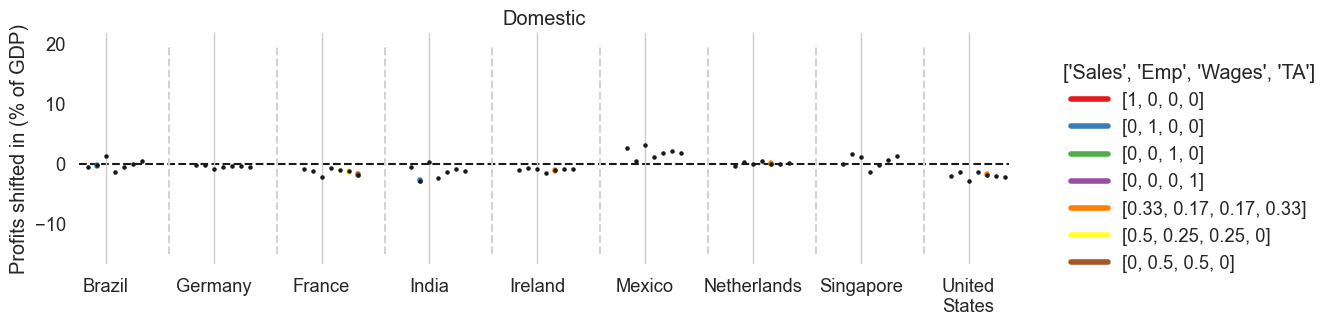

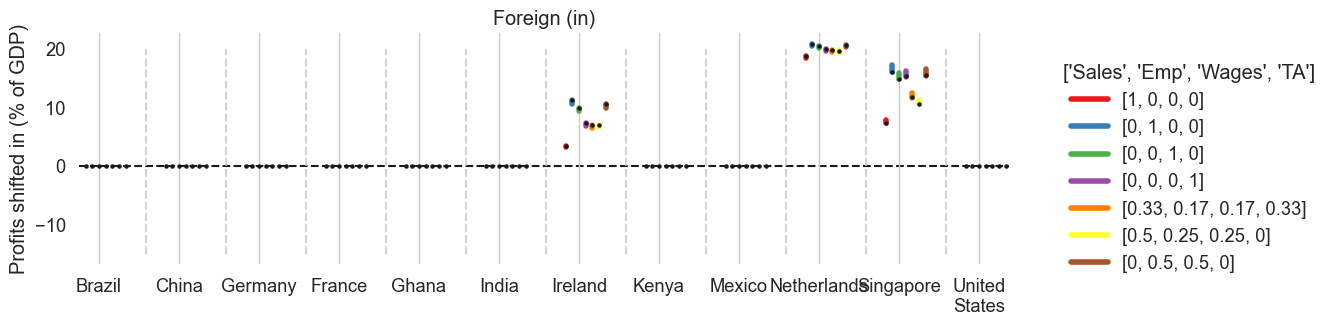

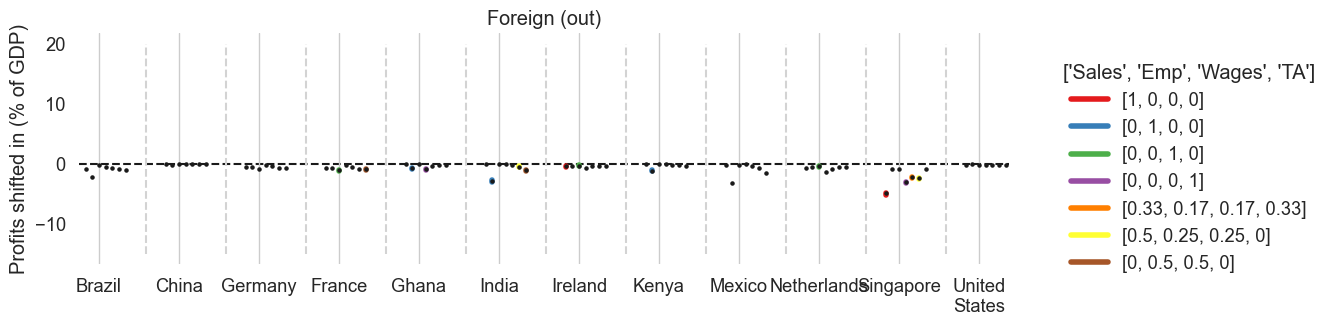

In [23]:
d_results = dict()
for weigths in [[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1],[1/3,1/6,1/6,1/3],[1/2,1/4,1/4,0],[0,0.5,0.5,0]]:
    weigths = weigths/np.sum(weigths)
    print(weigths)
    all_reps =  []
    all_pi =  []

    for rep,data in df.groupby("n_rep"):
        data = calculate_misalignment(data,weights=weigths,
                                      weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                      carve_out=None,
                                      carve_out_perc=0.2,
                                      pi_var="profits",
                                     thres_mis=0,
                                     max_etr=0.15)
        data.loc[(data["Domestic"]==0)&(data["misaligned_profits"]<0),"Domestic"] = -1
        data["Domestic"] = data["Domestic"].map({1: "Domestic", 0: "Foreign (in)", -1: "Foreign (out)"})
        all_reps.append(data.groupby(["iso3_d","Domestic"])["misaligned_profits"].sum())
#         all_pi.append(data.groupby(["iso3_d","Domestic"])["profits"].sum())

    df_all_reps = pd.concat(all_reps,axis=1)
#     df_all_pi = pd.concat(all_pi,axis=1)
    d_results[tuple(weigths)] = df_all_reps#[df_all_reps,df_all_pi]

all_w = []
for weights in d_results:
    d = d_results[weights].apply(lambda x: np.percentile(x[np.isfinite(x)],[2.5,25,50,75,97.5]).round(0),axis=1).reset_index()
    d[0] /= d["iso3_d"].map(iso3_to_gdp)    
    d[weights] = d[0]#.apply(lambda x: f"{x[1]:2.1%},{x[3]:2.1%}")

    del d[0]
    all_w.append(d.set_index(["iso3_d","Domestic"]))
    
d =  pd.concat(all_w,axis=1).reset_index()
# d["Domestic"] = d["Domestic"].replace({0:"Foreign MNCs", 1:"Domestic MNCs"})
d["etr"] = (100*d["iso3_d"].map(iso3_to_etr)).round(0)

w2c = dict(zip(d_results.keys(),sns.color_palette("Set1",7)))
plot_results(countries,w2c,restriction="Domestic")
plot_results(countries,w2c,restriction="Foreign (in)")
plot_results(countries,w2c,restriction="Foreign (out)")

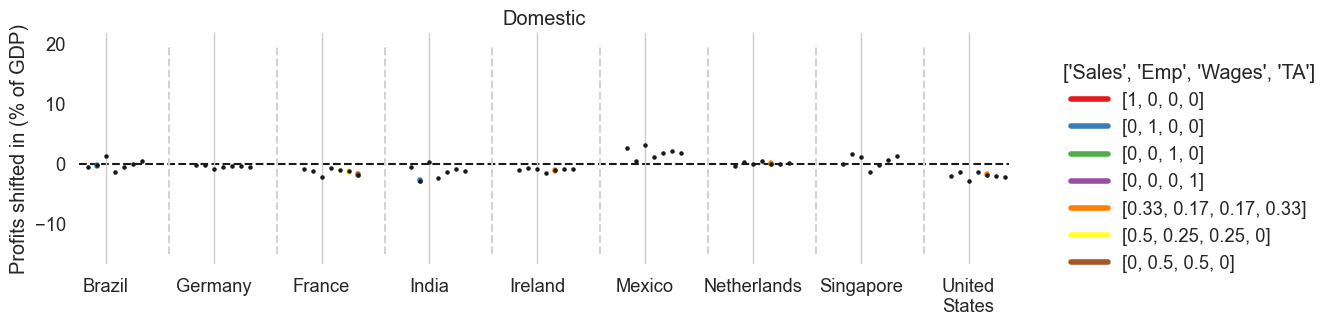

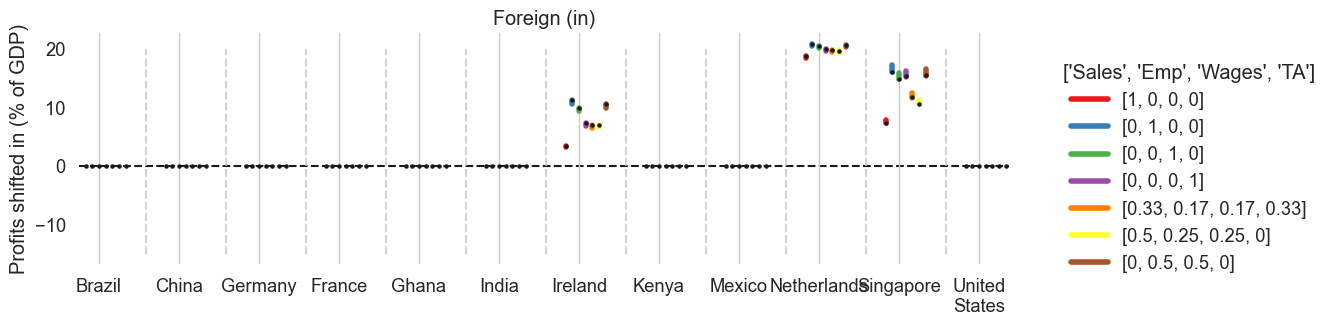

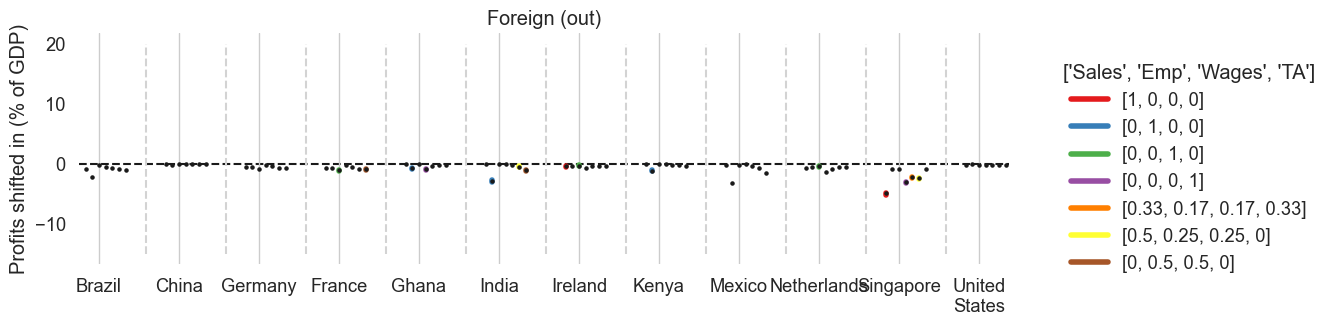

In [24]:
w2c = dict(zip(d_results.keys(),sns.color_palette("Set1",7)))
plot_results(countries,w2c,restriction="Domestic")
plot_results(countries,w2c,restriction="Foreign (in)")
plot_results(countries,w2c,restriction="Foreign (out)")

In [25]:
d = d_results[(0,0.5,0.5,0)].apply(lambda x: np.percentile(x[np.isfinite(x)],[2.5,25,50,75,97.5]).round(0),axis=1).reset_index()
d["ETR (%)"] = (100*d["iso3_d"].map(iso3_to_etr)).round(0)
d["cit"] = (100*d["iso3_d"].map(iso3_to_cit)).round(0)
d["gdp"] = (d["iso3_d"].map(iso3_to_gdp)).round(0)
d["sort"] = d[0].str[2]
d["PS (M)"] = d[0].str[2].apply(lambda x: f"{x/1E6:2,.0f}")
d["CI (M)"] = d.apply(lambda x: f"({x[0][0]/1E6:2,.0f}, {x[0][-1]/1E6:2,.0f})", axis=1)
d["PS (% GDP)"] = 100*d[0].str[2]/d["gdp"]
d["CI (% GDP)"] = d.apply(lambda x: f"({x[0][0]/x['gdp']:2.1%}, {x[0][-1]/x['gdp']:2.1%})", axis=1)
d["Type"] = d["Domestic"].map({0: "Foreign MNCs", 1: "Domestic MNCs"})
d["Country"] = d["iso3_d"].map(iso3_to_name)
display(d.sort_values(by="sort").tail(10)[["Country","Type","PS (M)", "PS (% GDP)", "CI (M)", "CI (% GDP)","ETR (%)"]])
display(d.sort_values(by="sort").head(10)[["Country","Type","PS (M)", "PS (% GDP)", "CI (M)", "CI (% GDP)","ETR (%)"]])

,Country,Type,PS (M),PS (% GDP),CI (M),CI (% GDP),ETR (%)
233,Luxembourg,NaN,"37,832",53.283634,"(37,727, 40,858)","(53.1%, 57.5%)",3.0
62,Canada,NaN,"40,037",2.320571,"(39,842, 40,096)","(2.3%, 2.3%)",17.0
182,Ireland,NaN,"40,712",10.554457,"(38,336, 40,756)","(9.9%, 10.6%)",12.0
92,Cayman Islands,NaN,"41,215",745.252817,"(37,422, 41,290)","(676.7%, 746.6%)",2.0
66,Switzerland,NaN,"51,976",7.163423,"(50,640, 54,819)","(7.0%, 7.6%)",11.0
342,Singapore,NaN,"58,488",15.514130,"(57,936, 62,238)","(15.4%, 16.5%)",10.0
47,Bermuda,NaN,"75,545",1045.465930,"(68,342, 79,447)","(945.8%, 1099.5%)",1.0
134,United Kingdom,NaN,"117,148",4.070247,"(116,404, 117,724)","(4.0%, 4.1%)",8.0
334,Saudi Arabia,NaN,"136,876",16.762138,"(136,851, 136,884)","(16.8%, 16.8%)",0.0
290,Netherlands,NaN,"188,643",20.638321,"(185,316, 189,193)","(20.3%, 20.7%)",6.0


,Country,Type,PS (M),PS (% GDP),CI (M),CI (% GDP),ETR (%)
393,United States,NaN,"-468,456",-2.281471,"(-472,686, -465,132)","(-2.3%, -2.3%)",23.0
133,United Kingdom,NaN,"-69,400",-2.411280,"(-69,936, -68,934)","(-2.4%, -2.4%)",8.0
126,France,NaN,"-51,390",-1.841306,"(-51,908, -51,009)","(-1.9%, -1.8%)",23.0
395,United States,NaN,"-43,020",-0.209518,"(-43,460, -42,907)","(-0.2%, -0.2%)",23.0
178,India,NaN,"-33,925",-1.255113,"(-34,224, -33,683)","(-1.3%, -1.2%)",41.0
180,India,NaN,"-30,360",-1.123235,"(-32,051, -28,794)","(-1.2%, -1.1%)",41.0
101,Germany,NaN,"-29,500",-0.742247,"(-29,774, -29,422)","(-0.7%, -0.7%)",19.0
128,France,NaN,"-27,867",-0.998458,"(-28,765, -27,798)","(-1.0%, -1.0%)",23.0
99,Germany,NaN,"-24,497",-0.616359,"(-24,976, -24,247)","(-0.6%, -0.6%)",19.0
53,Brazil,NaN,"-21,776",-1.135992,"(-21,810, -21,631)","(-1.1%, -1.1%)",25.0


In [26]:
iso3_to_dom["CAN"]

1

In [27]:
d.loc[d["iso3_d"]=="BRA"]

,iso3_d,Domestic,0,ETR (%),cit,gdp,sort,PS (M),CI (M),PS (% GDP),CI (% GDP),Type,Country
51,BRA,Domestic,"[7170326332.0, 7223339309.0, 7282242618.0, 730...",25.0,34.0,1.916947e+12,7.282243e+09,"7,282","(7,170, 7,317)",0.379888,"(0.4%, 0.4%)",NaN,Brazil
52,BRA,Foreign (in),"[0.0, 0.0, 0.0, 0.0, 0.0]",25.0,34.0,1.916947e+12,0.000000e+00,0,"( 0, 0)",0.000000,"(0.0%, 0.0%)",NaN,Brazil
53,BRA,Foreign (out),"[-21809572860.0, -21793839524.0, -21776358040....",25.0,34.0,1.916947e+12,-2.177636e+10,"-21,776","(-21,810, -21,631)",-1.135992,"(-1.1%, -1.1%)",NaN,Brazil


In [28]:
cost = []
costetr = []
mis = []
for weigths in [[0,0.5,0.5,0]]:
    weigths = weigths/np.sum(weigths)
    print(weigths)
    all_reps =  []
    all_pi =  []

    for rep,data in df.groupby("n_rep"):
        data = calculate_misalignment(data,weights=weigths,
                                      weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                      carve_out=None,
                                      carve_out_perc=0,
                                      pi_var="profits",
                                     thres_mis=0,
                                     max_etr=0.15)
        data["cit"] = data["iso3_d"].map(iso3_to_cit)
        data["cost"] = data["misaligned_profits"]*data["cit"]
        data["costetr"] = data["misaligned_profits"]*data["etr"]
        data = data.loc[data["misaligned_profits"]<0]
        mis.append(data["misaligned_profits"].sum())
        cost.append(data["cost"].sum())
        costetr.append(data["costetr"].sum())
        

[0.  0.5 0.5 0. ]


In [29]:
(np.percentile(mis,[2.5,50,97.5])/1E9).round(0)

array([-1109., -1100., -1092.])

In [30]:
(np.percentile(costetr,[2.5,50,97.5])/1E9).round(0)

array([-239., -238., -236.])

In [31]:
(np.percentile(cost,[2.5,50,97.5])/1E9).round(0)

array([-303., -302., -299.])

In [32]:
data

,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,n_rep,wages_pred,etr,cit,gdp,share_emp_pred,share_wages_pred,share_economy,share_profits,pi_theo_mis,misaligned_profits,cost,costetr
4708,ARG,CHE,0.0,20788.516312,5.825018e+09,2.215194e+09,1.398864e+08,1.303274,15951.0,4.469528e+09,1.699715e+09,1.073346e+08,2.0,1.638842e+08,0.153573,0.300,5.248197e+11,1.614945e-04,4.196195e-05,1.017282e-04,3.342051e-05,4.257983e+08,-1.981952e+08,-5.945856e+07,-3.043749e+07
4709,ARG,CHL,0.0,56625.932244,8.952083e+09,6.224575e+09,6.664710e+08,1.303274,43449.0,6.868921e+09,4.776108e+09,5.113823e+08,2.0,4.464049e+08,0.153573,0.300,5.248197e+11,4.398957e-04,1.143003e-04,2.770980e-04,1.592278e-04,1.159834e+09,-3.420010e+08,-1.026003e+08,-5.252223e+07
4711,ARG,DEU,0.0,37022.091585,1.362297e+10,6.066413e+09,2.313324e+08,1.303274,28407.0,1.045288e+10,4.654750e+09,1.775010e+08,2.0,2.918600e+08,0.153573,0.300,5.248197e+11,2.876042e-04,7.472968e-05,1.811670e-04,5.526803e-05,7.583006e+08,-3.652963e+08,-1.095889e+08,-5.609976e+07
4712,ARG,DNK,0.0,3954.131935,9.172081e+08,2.679235e+08,6.300078e+07,1.303274,3034.0,7.037725e+08,2.055773e+08,4.834041e+07,2.0,3.117200e+07,0.153573,0.300,5.248197e+11,3.071747e-05,7.981478e-06,1.934948e-05,1.505163e-05,8.099004e+07,-1.247022e+07,-3.741067e+06,-1.915093e+06
4714,ARG,FRA,0.0,68105.165626,1.417483e+10,4.259938e+09,1.764593e+08,1.303274,52257.0,1.087633e+10,3.268644e+09,1.353969e+08,2.0,5.369003e+08,0.153573,0.300,5.248197e+11,5.290715e-04,1.374714e-04,3.332714e-04,4.215820e-05,1.394956e+09,-8.446663e+08,-2.533999e+08,-1.297182e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,NPL,JPN,0.0,312.283121,2.282174e+07,7.917154e+06,2.914988e+06,2.001815,156.0,1.140053e+07,3.954988e+06,1.456173e+06,2.0,5.978869e+05,0.268861,0.200,3.311153e+10,2.425956e-06,1.530868e-07,1.289521e-06,6.964250e-07,5.397478e+06,-1.720871e+06,-3.441743e+05,-4.626746e+05
7041,SDN,SAU,0.0,2560.000000,6.088536e+08,2.003509e+08,3.197342e+07,10.000000,256.0,6.088536e+07,2.003509e+07,3.197342e+06,2.0,3.555514e+06,0.030422,0.350,3.233378e+10,1.988723e-05,9.103764e-07,1.039880e-05,7.638827e-06,4.352570e+07,-8.008085e+06,-2.802830e+06,-2.436213e+05
7043,VIR,IDN,0.0,1455.320156,1.069759e+08,3.051545e+07,4.628043e+06,2.018475,721.0,5.299837e+07,1.511808e+07,2.292842e+06,2.0,4.039192e+07,0.002349,0.231,3.922000e+09,1.130558e-05,1.034220e-05,1.082389e-05,1.105694e-06,4.530498e+07,-2.819739e+07,-6.513598e+06,-6.623034e+04
7045,VIR,USA,0.0,4856.449787,3.376741e+09,9.011067e+08,-1.759274e+08,2.018475,2406.0,1.672917e+09,4.464296e+08,-8.715857e+07,2.0,1.347891e+08,0.002349,0.231,3.922000e+09,3.772708e-05,3.451226e-05,3.611967e-05,-4.203112e-05,1.511841e+08,-2.267549e+08,-5.238037e+07,-5.326042e+05


In [33]:
countries = "IRL, NLD, SGP, FRA, DEU, USA, BRA, IND, MEX, GHA, KEN, CHN".split(", ")

(1.0, 0.0, 0.0, 0.0) [966.58899539 970.88642945 976.61926975]
(0.0, 1.0, 0.0, 0.0) [1194.61806306 1201.26138886 1206.27791398]
(0.0, 0.0, 1.0, 0.0) [1111.10272468 1119.0104562  1128.80032104]
(0.0, 0.0, 0.0, 1.0) [895.17906279 901.69853572 905.69545123]
(0.3333333333333333, 0.16666666666666666, 0.16666666666666666, 0.3333333333333333) [895.78751151 902.96307825 911.50513567]
(0.5, 0.25, 0.25, 0.0) [977.04089404 984.14818988 993.38419408]
(0.0, 0.5, 0.5, 0.0) [1091.94349841 1100.17503663 1109.0936438 ]


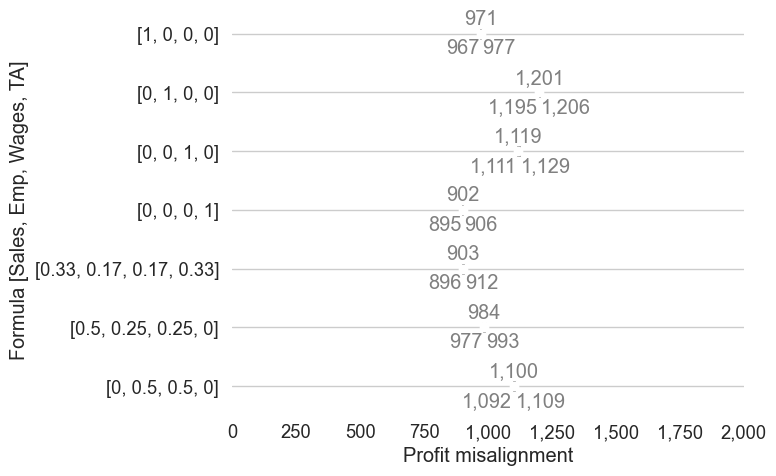

In [36]:
plt.figure(figsize=(8,5))
i = 0
for alpha in d_results:
    i += 1
    d = d_results[alpha].copy()#.xs(i, level='Domestic', drop_level=False)
    d[d<0] = 0
    d = d.groupby("iso3_d").sum()
    
    perc = np.percentile(d.sum(),[2.5,50,97.5])/1E9
    print(alpha,perc)
    plt.barh(i,perc[-1]-perc[0],left=perc[0],color="gray",height=0.2)
    plt.scatter(perc[1],i,color="white",zorder=9)
    plt.annotate(f"{perc[1]:2,.0f}",(perc[1],i-0.25),va="center",ha="center",color="gray")
    plt.annotate(f"{perc[0]:2,.0f}",(perc[0],i+0.25),va="center",ha="right",color="gray")
    plt.annotate(f"{perc[-1]:2,.0f}",(perc[-1],i+0.25),va="center",ha="left",color="gray")
    
plt.yticks(range(1,i+1),[[np.round(_,2) if _!=int(_) else int(_) for _ in k] for k in d_results.keys()])
plt.gca().grid(axis="x")
sns.despine(bottom=True,left=True)
plt.xlim(0,2000)
plt.xlabel("Profit misalignment")
plt.ylabel("Formula [Sales, Emp, Wages, TA]")
plt.gca().invert_yaxis()


plt.gca().xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig(f"{path_files_temp}/test_new.png",dpi=300)
plt.savefig(f"{path_files_final_figures}/test_new.png",dpi=300)